In [1]:
import pandas as pd
import h5py
import numpy as np

CSV_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'
H5_PATH  = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'

df = pd.read_csv(CSV_PATH)
h5f = h5py.File(H5_PATH, "r")

# contoh filter: local EQ, R <= 20 km, Mw >= 3
df_nf = df[
    (df.trace_category == "earthquake_local") &
    (df.source_distance_km <= 20) &
    (df.source_magnitude >= 3.0)
].reset_index(drop=True)

len(df_nf)


/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_2637/3435550589.py:8: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


2515

In [ ]:
# 1. Melihat grup utama (label) yang ada di dalam file HDF5
print("Daftar Label/Grup utama dalam file H5:")
labels = list(h5f.keys())
print(labels)

# 2. Melihat struktur data di dalam salah satu grup (misal grup pertama)
if len(labels) > 0:
    first_label = labels[0]
    print(f"\nContoh isi di dalam grup '{first_label}':")
    # Menampilkan 5 contoh nama trace/data pertama
    print(list(h5f[first_label].keys())[:5])

# 3. Melihat kolom apa saja yang ada di file CSV (Metadata)
print("\nKolom (Label Metadata) yang tersedia di CSV:")
print(df.columns.tolist())

Daftar Label/Grup utama dalam file H5:
['data']

Contoh isi di dalam grup 'data':
['109C.TA_20060723155859_EV', '109C.TA_20061103155652_EV', '109C.TA_20061103161223_EV', '109C.TA_20061114133221_EV', '109C.TA_20061127104640_EV']

Kolom (Label Metadata) yang tersedia di CSV:
['network_code', 'receiver_code', 'receiver_type', 'receiver_latitude', 'receiver_longitude', 'receiver_elevation_m', 'p_arrival_sample', 'p_status', 'p_weight', 'p_travel_sec', 's_arrival_sample', 's_status', 's_weight', 'source_id', 'source_origin_time', 'source_origin_uncertainty_sec', 'source_latitude', 'source_longitude', 'source_error_sec', 'source_gap_deg', 'source_horizontal_uncertainty_km', 'source_depth_km', 'source_depth_uncertainty_km', 'source_magnitude', 'source_magnitude_type', 'source_magnitude_author', 'source_mechanism_strike_dip_rake', 'source_distance_deg', 'source_distance_km', 'back_azimuth_deg', 'snr_db', 'coda_end_sample', 'trace_start_time', 'trace_category', 'trace_name']


Daftar Label/Grup utama dalam file H5:
['data']

Contoh isi di dalam grup 'data':


KeyboardInterrupt: 

In [3]:
# 1. Pilih satu nama label/trace dari list yang kita dapat tadi
# Saya menggunakan index [0] dari hasil filter kamu (df_nf)
sample_name = df_nf.iloc[0]['trace_name']
dataset = h5f['data'][sample_name]

print(f"--- Eksplorasi Label: {sample_name} ---")

# 2. Menampilkan dimensi data
print(f"Bentuk Data (Shape): {dataset.shape}")
print(f"Tipe Data: {dataset.dtype}")

# 3. Menampilkan isi atribut (Metadata internal di dalam H5 jika ada)
print("\nAtribut yang tersimpan di label ini:")
if len(dataset.attrs) == 0:
    print("Tidak ada atribut tambahan di dalam dataset ini.")
else:
    for attr_name, attr_value in dataset.attrs.items():
        print(f"- {attr_name}: {attr_value}")

# 4. Menampilkan cuplikan data (5 sampel pertama, 3 komponen)
data_array = np.array(dataset)
print("\nCuplikan isi data (5 sampel pertama, 3 komponen):")
print(data_array[:5])

--- Eksplorasi Label: A16.CN_20150121053158_EV ---
Bentuk Data (Shape): (6000, 3)
Tipe Data: float32

Atribut yang tersimpan di label ini:
- back_azimuth_deg: 56.900001525878906
- coda_end_sample: [[1228.]]
- network_code: CN
- p_arrival_sample: 400.0
- p_status: manual
- p_travel_sec: 4.630000114440918
- p_weight: 0.5
- receiver_code: A16
- receiver_elevation_m: 13.0
- receiver_latitude: 47.468
- receiver_longitude: -70.0096
- receiver_type: HH
- s_arrival_sample: 686.0
- s_status: manual
- s_weight: 0.5
- snr_db: [72.40000153 61.70000076 62.20000076]
- source_depth_km: 17.420000076293945
- source_depth_uncertainty_km: 7.599999904632568
- source_distance_deg: 0.18000000715255737
- source_distance_km: 19.209999084472656
- source_error_sec: 0.8797000050544739
- source_gap_deg: 37.69900131225586
- source_horizontal_uncertainty_km: 2.6865499019622803
- source_id: 606589340
- source_latitude: 47.3748
- source_longitude: -70.2239
- source_magnitude: 3.7
- source_magnitude_author: None
- sou

Menampilkan data untuk trace: A16.CN_20150121053158_EV


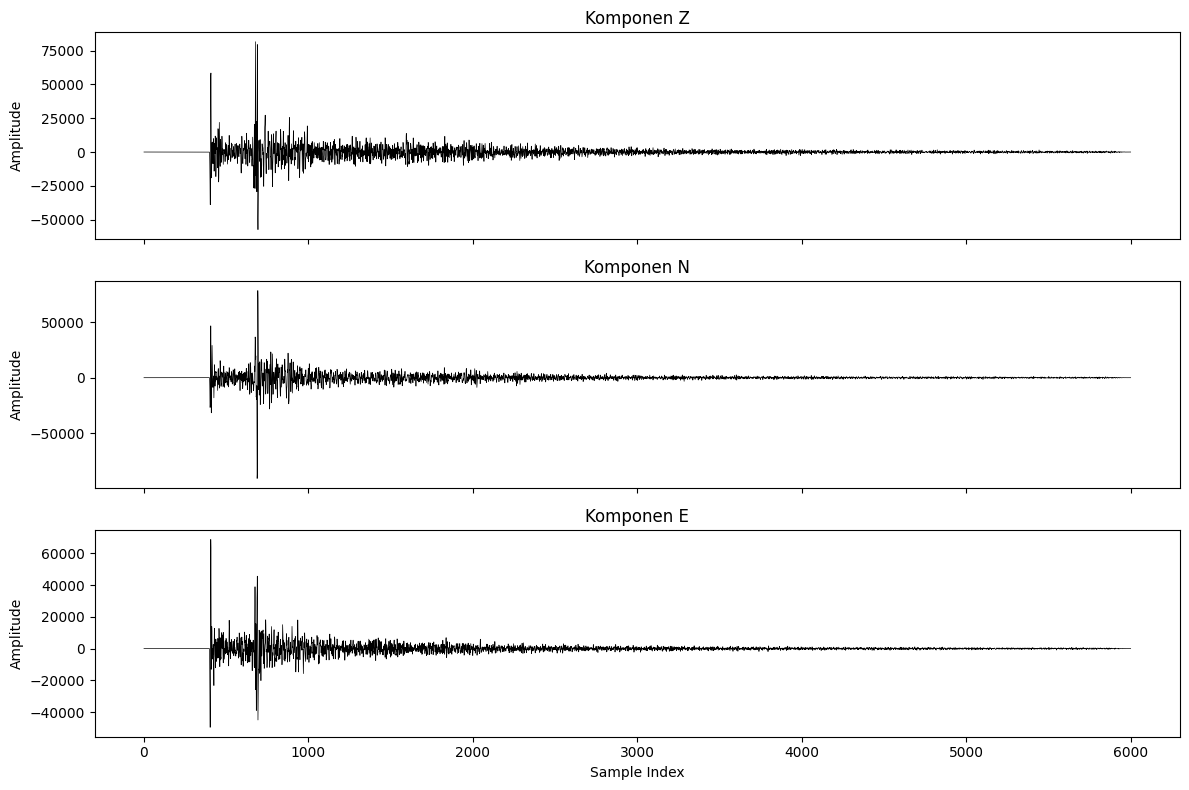

In [6]:
import matplotlib.pyplot as plt

# 1. Pilih satu contoh trace dari data yang sudah difilter (misal baris pertama)
sample_trace_name = df_nf.iloc[0]['trace_name']
print(f"Menampilkan data untuk trace: {sample_trace_name}")

# 2. Ambil data dari file H5
# Pastikan path-nya benar: h5f['nama_grup']['nama_dataset']
data_gelombang = h5f['data'][sample_trace_name]

# Konversi ke numpy array (biasanya bentuknya (3, jumlah_sample))
data_array = np.array(data_gelombang)

# 3. Visualisasi 3 komponen (Z, N, E)
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

komponen = ['Komponen Z', 'Komponen N', 'Komponen E']
for i in range(3):
    ax[i].plot(data_array[:, i], color='black', linewidth=0.5)
    ax[i].set_ylabel('Amplitude')
    ax[i].set_title(komponen[i])

ax[2].set_xlabel('Sample Index')
plt.tight_layout()
plt.show()

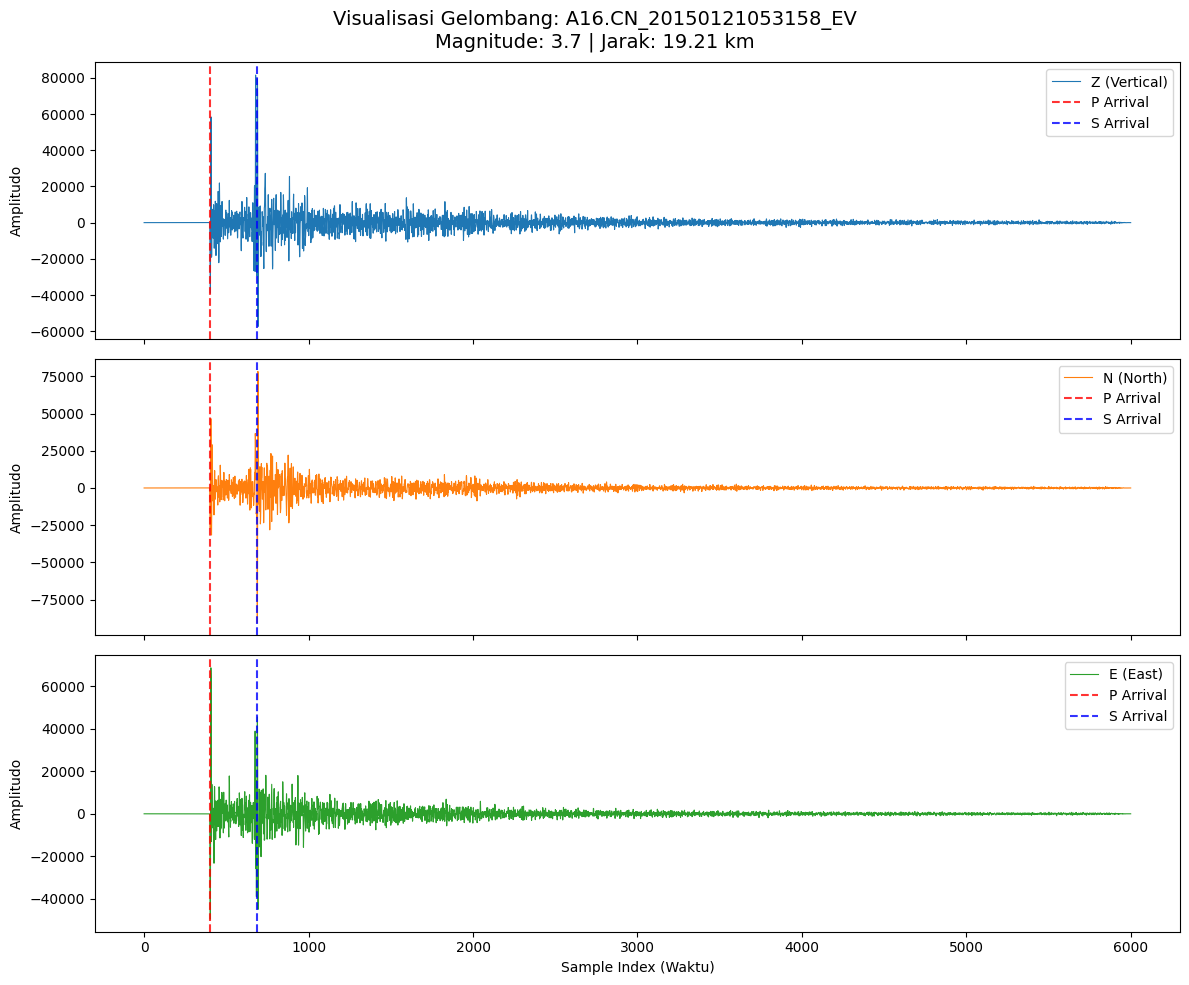

In [7]:
import matplotlib.pyplot as plt

# 1. Ambil data gelombang dan atributnya
data_array = np.array(h5f['data'][sample_name])
p_idx = dataset.attrs['p_arrival_sample']
s_idx = dataset.attrs['s_arrival_sample']

# 2. Plotting
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Warna berbeda untuk tiap komponen
labels = ['Z (Vertical)', 'N (North)', 'E (East)']

for i in range(3):
    ax[i].plot(data_array[:, i], color=colors[i], label=labels[i], linewidth=0.8)
    
    # Menambahkan garis vertikal untuk P dan S arrival
    ax[i].axvline(x=p_idx, color='red', linestyle='--', alpha=0.8, label='P Arrival')
    ax[i].axvline(x=s_idx, color='blue', linestyle='--', alpha=0.8, label='S Arrival')
    
    ax[i].legend(loc='upper right')
    ax[i].set_ylabel('Amplitudo')

ax[2].set_xlabel('Sample Index (Waktu)')
plt.suptitle(f"Visualisasi Gelombang: {sample_name}\nMagnitude: {dataset.attrs['source_magnitude']} | Jarak: {dataset.attrs['source_distance_km']:.2f} km", fontsize=14)
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

# 1. Menyiapkan Data Atribut (Metadata)
# Kita ubah dictionary atribut menjadi DataFrame
attrs_dict = dict(dataset.attrs)
df_metadata = pd.DataFrame(list(attrs_dict.items()), columns=['Parameter', 'Value'])

# 2. Menyiapkan Data Gelombang (Waveform)
# Kita buat DataFrame dengan kolom Z, N, dan E
df_waveform = pd.DataFrame(data_array, columns=['Component_Z', 'Component_N', 'Component_E'])
# Menambahkan kolom index sampel agar lebih jelas di Excel
df_waveform.insert(0, 'Sample_Index', range(len(df_waveform)))

# 3. Menyimpan ke File Excel dengan dua Sheet
file_name = f"{sample_name}.xlsx"

with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    df_metadata.to_excel(writer, sheet_name='Metadata', index=False)
    df_waveform.to_excel(writer, sheet_name='Waveform_Data', index=False)

print(f"Berhasil! File telah disimpan dengan nama: {file_name}")

Berhasil! File telah disimpan dengan nama: A16.CN_20150121053158_EV.xlsx


In [12]:
# 1. Menghitung total data per kategori (Event vs Noise)
kategori_counts = df['trace_category'].value_counts()

print("--- Distribusi Label dalam Dataset ---")
print(kategori_counts)
print("-" * 40)

# 2. Menampilkan contoh label untuk tiap kategori
# Perhatikan kata kunci 'in' di bawah ini:
for kategori in kategori_counts.index:
    print(f"\nKategori: {kategori}")
    
    # Mengambil 3 contoh nama trace untuk kategori ini
    contoh_trace = df[df['trace_category'] == kategori]['trace_name'].head(3).tolist()
    
    for i, name in enumerate(contoh_trace, 1):
        print(f"  {i}. {name}")

--- Distribusi Label dalam Dataset ---
trace_category
earthquake_local    1030231
noise                235426
Name: count, dtype: int64
----------------------------------------

Kategori: earthquake_local
  1. 109C.TA_20060723155859_EV
  2. 109C.TA_20061103155652_EV
  3. 109C.TA_20061103161223_EV

Kategori: noise
  1. 113A.AE_20180115001730_NO
  2. 113A.AE_20180115003336_NO
  3. 113A.AE_20180115020106_NO


In [13]:
# 1. Mengambil semua jenis kategori yang unik
semua_kategori = df['trace_category'].unique()

print("--- Jenis Kategori yang Ditemukan ---")
print(semua_kategori)
print("-" * 40)

# 2. Memisahkan dan menampilkan nama-nama (trace_name)
for kat in semua_kategori:
    # Filter dataframe berdasarkan kategori saat ini
    daftar_nama = df[df['trace_category'] == kat]['trace_name'].unique()
    
    print(f"\nKategori: {kat.upper()}")
    print(f"Jumlah total data: {len(daftar_nama)}")
    print("Contoh 5 nama teratas:")
    
    # Menampilkan 5 contoh saja agar tidak memenuhi layar
    for i, nama in enumerate(daftar_nama[:5], 1):
        print(f"  {i}. {nama}")

--- Jenis Kategori yang Ditemukan ---
['noise' 'earthquake_local']
----------------------------------------

Kategori: NOISE
Jumlah total data: 235426
Contoh 5 nama teratas:
  1. 113A.AE_20180115001730_NO
  2. 113A.AE_20180115003336_NO
  3. 113A.AE_20180115020106_NO
  4. 113A.AE_20180115022906_NO
  5. 113A.AE_20180115035100_NO

Kategori: EARTHQUAKE_LOCAL
Jumlah total data: 1030231
Contoh 5 nama teratas:
  1. 109C.TA_20060723155859_EV
  2. 109C.TA_20061103155652_EV
  3. 109C.TA_20061103161223_EV
  4. 109C.TA_20061114133221_EV
  5. 109C.TA_20061127104640_EV


In [14]:
# Menyimpan daftar nama event ke file teks
event_names = df[df['trace_category'].str.contains('earthquake')]['trace_name']
event_names.to_csv('daftar_event.txt', index=False, header=False)

print("\nFile 'daftar_event.txt' telah dibuat!")


File 'daftar_event.txt' telah dibuat!


In [15]:
# 1. Mencari semua kategori unik di seluruh dataset
kategori_unik = df['trace_category'].unique()

print("--- Mencari Kategori Selain Earthquake & Noise ---")

# 2. Menampilkan kategori yang ditemukan
for kat in kategori_unik:
    # Menghitung berapa banyak data di kategori ini
    jumlah = len(df[df['trace_category'] == kat])
    
    # Memberikan keterangan sederhana berdasarkan nama kategori
    keterangan = ""
    if "earthquake" in kat.lower():
        keterangan = "-> (Kategori Gempa)"
    elif "noise" in kat.lower():
        keterangan = "-> (Kategori Gangguan/Latar Belakang)"
    else:
        keterangan = "-> (KATEGORI LAIN/KHUSUS!)"
    
    print(f"- {kat:<20} : {jumlah:>6} data {keterangan}")

# 3. Menampilkan contoh data jika ditemukan kategori "aneh"
kategori_non_standar = [k for k in kategori_unik if "earthquake" not in k.lower() and "noise" not in k.lower()]

if kategori_non_standar:
    print("\n--- Contoh Trace dari Kategori Lain ---")
    for kat_lain in kategori_non_standar:
        contoh = df[df['trace_category'] == kat_lain]['trace_name'].iloc[0]
        print(f"Kategori '{kat_lain}': Contoh ID -> {contoh}")
else:
    print("\nTidak ditemukan kategori selain Earthquake dan Noise.")

--- Mencari Kategori Selain Earthquake & Noise ---
- noise                : 235426 data -> (Kategori Gangguan/Latar Belakang)
- earthquake_local     : 1030231 data -> (Kategori Gempa)

Tidak ditemukan kategori selain Earthquake dan Noise.


In [4]:
# Cara 1: Menampilkan semua nama kolom sebagai list Python
kolom_stead = df_nf.columns.tolist()
print("Daftar Kolom STEAD:")
print(kolom_stead)

print("-" * 50)

# Cara 2: Melihat nama kolom secara vertikal (lebih nyaman dibaca)
print("Daftar Kolom (Vertikal):")
for col in df_nf.columns:
    print(f"- {col}")

print("-" * 50)

# Cara 3: Menampilkan nama kolom sekaligus tipe data dan jumlah nilai Non-Null
print("Informasi Detail DataFrame:")
df_nf.info()

Daftar Kolom STEAD:
['network_code', 'receiver_code', 'receiver_type', 'receiver_latitude', 'receiver_longitude', 'receiver_elevation_m', 'p_arrival_sample', 'p_status', 'p_weight', 'p_travel_sec', 's_arrival_sample', 's_status', 's_weight', 'source_id', 'source_origin_time', 'source_origin_uncertainty_sec', 'source_latitude', 'source_longitude', 'source_error_sec', 'source_gap_deg', 'source_horizontal_uncertainty_km', 'source_depth_km', 'source_depth_uncertainty_km', 'source_magnitude', 'source_magnitude_type', 'source_magnitude_author', 'source_mechanism_strike_dip_rake', 'source_distance_deg', 'source_distance_km', 'back_azimuth_deg', 'snr_db', 'coda_end_sample', 'trace_start_time', 'trace_category', 'trace_name']
--------------------------------------------------
Daftar Kolom (Vertikal):
- network_code
- receiver_code
- receiver_type
- receiver_latitude
- receiver_longitude
- receiver_elevation_m
- p_arrival_sample
- p_status
- p_weight
- p_travel_sec
- s_arrival_sample
- s_status


In [6]:
import pandas as pd

# Sesuaikan path file dengan lokasi CSV BMKG Anda
BMKG_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/BMKG_Earthquake_Catalog_CLEAN_MB_ONLY.csv'
df_bmkg = pd.read_csv(BMKG_PATH)

print("Jumlah Data Gempa BMKG:", len(df_bmkg))
print("-" * 50)
print("Daftar Kolom Katalog BMKG:")
for col in df_bmkg.columns:
    print(f"- {col}")
    
print("-" * 50)
df_bmkg.head(3) # Melihat 3 baris pertama

Jumlah Data Gempa BMKG: 5989
--------------------------------------------------
Daftar Kolom Katalog BMKG:
- No
- Event ID
- Date
- Time (UTC)
- Latitude
- Longitude
- Magnitude
- Mag Type
- Depth (km)
- Source
- Source Event ID
- origin_time
--------------------------------------------------


,No,Event ID,Date,Time (UTC),Latitude,Longitude,Magnitude,Mag Type,Depth (km),Source,Source Event ID,origin_time
0,4,BMKG-19980129150524-001,29-Jan-1998,15:05:24,6.76,127.28,3.8,MB,33,RC_04,NaN,1998-01-29T15:05:24.000000Z
1,5,BMKG-19980205061524-001,05-Feb-1998,06:15:24,6.88,127.22,4.3,MB,33,RC_04,NaN,1998-02-05T06:15:24.000000Z
2,6,BMKG-19980210163811-001,10-Feb-1998,16:38:11,5.48,94.80,3.6,MB,100,RC_04,NaN,1998-02-10T16:38:11.000000Z


In [ ]:
import pandas as pd
from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees
import warnings

# Mengabaikan peringatan kecil agar tampilan terminal tetap bersih
warnings.filterwarnings("ignore")

# ==========================================
# 1. KONFIGURASI PATH DAN INISIALISASI
# ==========================================
CSV_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/BMKG_Earthquake_Catalog_CLEAN_MB_ONLY.csv'
CSV_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/usgs_katalog/katalog_usgs_master_2001_2025.csv'

print("Mempersiapkan koneksi ke IRIS dan Model Kecepatan Bumi...")
client = Client("IRIS")
model = TauPyModel(model="iasp91")

# Membaca data CSV
df_bmkg = pd.read_csv(CSV_PATH)
print(f"Katalog berhasil dimuat! Total data: {len(df_bmkg)}")

# List untuk menyimpan metadata yang sukses diunduh
metadata_sukses = []

# ==========================================
# 2. PROSES UNDUH DATA (TESTING 5 DATA PERTAMA)
# ==========================================
# HAPUS '.head(5)' jika Anda ingin memproses seluruh 5989 data
df_target = df_bmkg.head(5) 

print(f"\nMemulai proses pencarian untuk {len(df_target)} gempa...\n" + "="*50)

for index, row in df_target.iterrows():
    # Mengambil ID dan Waktu dari kolom yang sesuai dengan format katalog Anda
    event_id = row['Event ID']
    origin_time_str = row['origin_time']
    
    print(f"\n[{index+1}/{len(df_target)}] Memproses Gempa ID: {event_id} | Waktu: {origin_time_str}")
    
    eq_lat = float(row['Latitude'])
    eq_lon = float(row['Longitude'])
    eq_depth = float(row['Depth (km)'])
    
    try:
        eq_origin = UTCDateTime(origin_time_str)
    except Exception as e:
        print(">> [SKIP] Format waktu origin_time tidak valid.")
        continue

    try:
        # Mencari SEMUA stasiun di radius 3 derajat (~330 km)
        inventory = client.get_stations(
            network="IA,GE,II", 
            channel="BH?,HH?,EH?", 
            latitude=eq_lat, 
            longitude=eq_lon, 
            maxradius=3.0,      
            starttime=eq_origin,
            endtime=eq_origin + 3600,
            level="station"
        )
        
        data_berhasil_diunduh = False
        
        # Mencoba stasiun satu per satu
        for network in inventory:
            for station in network:
                net_code = network.code
                sta_code = station.code
                
                # Hitung jarak (derajat) dan kedatangan teoretis gelombang P
                distance_deg = locations2degrees(eq_lat, eq_lon, station.latitude, station.longitude)
                arrivals = model.get_travel_times(source_depth_in_km=eq_depth, distance_in_degree=distance_deg, phase_list=["P", "p"])
                
                if not arrivals: 
                    continue
                    
                p_arrival_time = eq_origin + arrivals[0].time
                
                # Window pemotongan ala STEAD: 5 detik sebelum P-Arrival, durasi 60 detik
                start_time = p_arrival_time - 5.0
                end_time = start_time + 60.0
                
                try:
                    # Request Waveform ke server IRIS
                    st = client.get_waveforms(net_code, sta_code, "*", "BH?,HH?,EH?", start_time, end_time)
                    
                    # Pre-processing: Detrend dan Resample ke 100 Hz
                    st.detrend('demean').detrend('linear').resample(100.0)
                    
                    print(f">> [SUKSES] Data diunduh dari Stasiun {net_code}.{sta_code}!")
                    
                    # Simpan informasi keberhasilan ke dalam list
                    metadata_sukses.append({
                        'Event ID': event_id,
                        'origin_time': origin_time_str,
                        'network_code': net_code,
                        'receiver_code': sta_code,
                        'p_arrival_time_teoretis': str(p_arrival_time),
                        'source_distance_deg': distance_deg
                    })
                    
                    data_berhasil_diunduh = True
                    break # Hentikan pencarian stasiun untuk gempa ini
                    
                except Exception:
                    # Jika Error 204 (Data kosong), coba stasiun berikutnya
                    continue 
            
            if data_berhasil_diunduh: break # Keluar dari loop jaringan jika sudah dapat
            
        if not data_berhasil_diunduh:
            print(">> [GAGAL] Semua stasiun terdekat offline atau data kosong (Error 204).")
            
    except Exception as e:
        print(f">> [GAGAL] Tidak ditemukan stasiun sama sekali di radius 3 derajat.")

# ==========================================
# 3. PENYIMPANAN LOG METADATA
# ==========================================
if metadata_sukses:
    df_sukses = pd.DataFrame(metadata_sukses)
    # Simpan di folder yang sama dengan CSV Anda
    output_path = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/Katalog_Unduh_Sukses.csv'
    df_sukses.to_csv(output_path, index=False)
    print(f"\nSelesai! Berhasil mengunduh {len(df_sukses)} gempa. Log disimpan di: {output_path}")
else:
    print("\nSelesai! Sayangnya belum ada data yang berhasil diunduh dari sampel ini.")

Mempersiapkan koneksi ke IRIS dan Model Kecepatan Bumi...
Katalog berhasil dimuat! Total data: 5989

Memulai proses pencarian untuk 5 gempa...

[1/5] Memproses Gempa ID: BMKG-19980129150524-001 | Waktu: 1998-01-29T15:05:24.000000Z
>> [GAGAL] Tidak ditemukan stasiun sama sekali di radius 3 derajat.

[2/5] Memproses Gempa ID: BMKG-19980205061524-001 | Waktu: 1998-02-05T06:15:24.000000Z
>> [GAGAL] Tidak ditemukan stasiun sama sekali di radius 3 derajat.

[3/5] Memproses Gempa ID: BMKG-19980210163811-001 | Waktu: 1998-02-10T16:38:11.000000Z
>> [GAGAL] Tidak ditemukan stasiun sama sekali di radius 3 derajat.

[4/5] Memproses Gempa ID: BMKG-19980214193954-001 | Waktu: 1998-02-14T19:39:54.000000Z
>> [GAGAL] Tidak ditemukan stasiun sama sekali di radius 3 derajat.

[5/5] Memproses Gempa ID: BMKG-19980214195135-001 | Waktu: 1998-02-14T19:51:35.000000Z
>> [GAGAL] Tidak ditemukan stasiun sama sekali di radius 3 derajat.

Selesai! Sayangnya belum ada data yang berhasil diunduh dari sampel ini.
